In [8]:
import pandas as pd

mood_data = pd.read_csv('fear_greed_index.csv')
trade_data = pd.read_csv('historical_data.csv')
print("Mood data size:", mood_data.shape)
print("Trade data size:", trade_data.shape)
print("\nMissing values in trades:")
print(trade_data.isnull().sum())
mood_data['match_date'] = pd.to_datetime(mood_data['date']).dt.date
trade_data['match_date'] = pd.to_datetime(trade_data['Timestamp IST'], dayfirst=True).dt.date
final_table = pd.merge(trade_data, mood_data[['match_date', 'classification']], on='match_date', how='inner')
print("\nSuccess! Here is a sample of the merged data:")
print(final_table[['Timestamp IST', 'classification', 'Closed PnL']].head())

Mood data size: (2644, 4)
Trade data size: (211224, 16)

Missing values in trades:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Success! Here is a sample of the merged data:
      Timestamp IST classification  Closed PnL
0  02-12-2024 22:50  Extreme Greed         0.0
1  02-12-2024 22:50  Extreme Greed         0.0
2  02-12-2024 22:50  Extreme Greed         0.0
3  02-12-2024 22:50  Extreme Greed         0.0
4  02-12-2024 22:50  Extreme Greed         0.0


/tmp/ipykernel_784/2729376343.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Market_Mood', y='Avg_Profit', palette='Blues_d')
/tmp/ipykernel_784/2729376343.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Market_Mood', y='Win_Rate', palette='Greens_d')
/tmp/ipykernel_784/2729376343.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Market_Mood', y='Total_Trades', palette='Oranges_d')


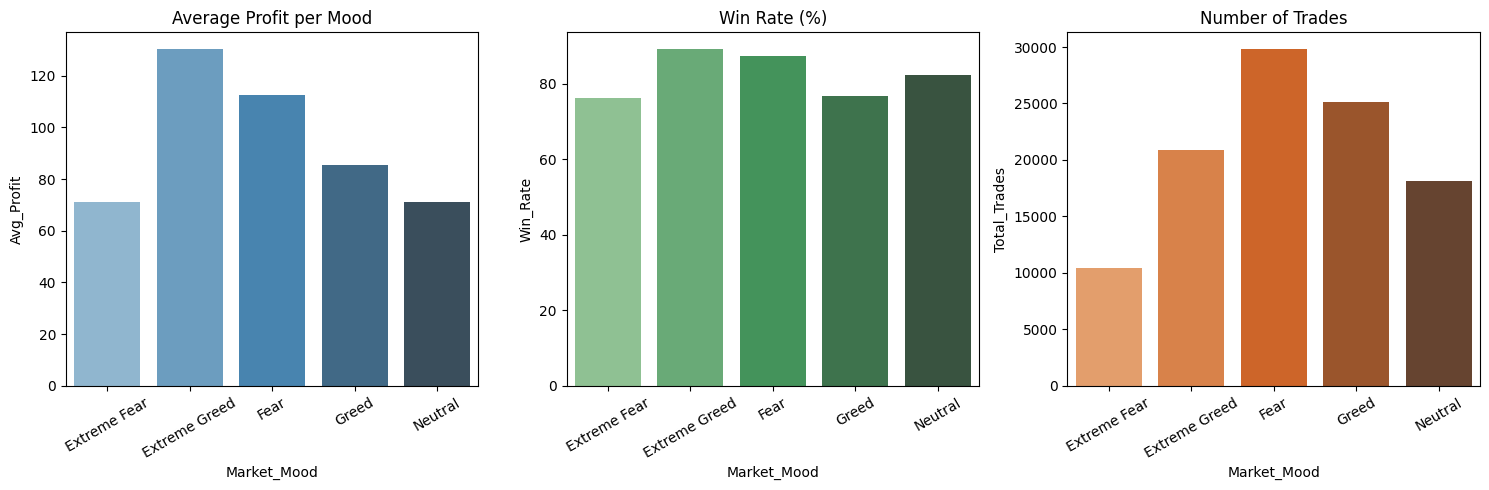

     Market_Mood  Avg_Profit  Total_Trades   Win_Rate
0   Extreme Fear   71.027316         10406  76.215645
1  Extreme Greed  130.205309         20853  89.167026
2           Fear  112.625988         29808  87.288647
3          Greed   85.403927         25176  76.890690
4        Neutral   71.199993         18159  82.388898


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
real_trades = final_table[final_table['Closed PnL'] != 0].copy()
summary = real_trades.groupby('classification')['Closed PnL'].agg(['mean', 'count']).reset_index()
summary.columns = ['Market_Mood', 'Avg_Profit', 'Total_Trades']
winning_trades = real_trades[real_trades['Closed PnL'] > 0].groupby('classification').size()
total_trades = real_trades.groupby('classification').size()
summary['Win_Rate'] = (winning_trades / total_trades).values * 100
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.barplot(data=summary, x='Market_Mood', y='Avg_Profit', palette='Blues_d')
plt.title('Average Profit per Mood')
plt.xticks(rotation=30)
plt.subplot(1, 3, 2)
sns.barplot(data=summary, x='Market_Mood', y='Win_Rate', palette='Greens_d')
plt.title('Win Rate (%)')
plt.xticks(rotation=30)
plt.subplot(1, 3, 3)
sns.barplot(data=summary, x='Market_Mood', y='Total_Trades', palette='Oranges_d')
plt.title('Number of Trades')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(summary)